# FlowState r1.1 Benchmarking

| | |
|---|---|
| **Organization** | IBM Research |
| **Version** | FlowState R1 (August 2025) |
| **Parameters** | ~9M |
| **Input Features** | Target series only |

## Key Characteristics

FlowState introduces a timescale-invariant forecasting approach through a two-component architecture. An SSM-based encoder maps input time series into a continuous latent space that is independent of the original sampling rate. The Functional Basis Decoder (FBD) then generates forecasts by projecting this representation onto a set of continuous basis functions, allowing adaptation to any target sampling rate at inference time via a scale factor parameter without retraining.

At time of release, FlowState ranked top 10 on the GIFT-Eval leaderboard for zero-shot models despite having more than 10 times fewer parameters than similar models. All reported results are zero-shot with no overlap between training and evaluation data.

---

**Validation split:** Train on periods 1–36, validate on 37–42 (identical to Notebook 6)  
**Target:** `Revenue cons. (anon)` at subsegment level  
**Runtime:** T4 GPU (Google Colab) — set manually: Runtime → Change runtime type → T4 GPU

---
## 1. Dependencies

In [6]:
!pip install -q git+https://github.com/ibm-granite/granite-tsfm.git@gift-flowstate

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 81.4 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 53.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 104.7 MB/s eta 0:00:00


In [7]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings('ignore')

print(f'GPU available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'Device: {torch.cuda.get_device_name(0)}')

GPU available: True
Device: Tesla T4


---
## 2. Configuration

In [8]:
# ── Constants ──
PERIOD_COL = 'Anon Period'
TARGET     = 'Revenue cons. (anon)'
SUBSEG_COL = 'TGL Business Subsegment'
VAL_CUTOFF = 36
HORIZON    = 6

# ── Paths ──
DATA_PATH  = '/content/drive/MyDrive/Coding/data/features/training_subsegment_fs.parquet'
VAL_PATH   = '/content/drive/MyDrive/Coding/data/features/validation_subsegment_fs.parquet'
OUTPUT_DIR = Path('/content/drive/MyDrive/Coding/data/predictions/')

---
## 3. Data & Function Loading

In [9]:
import sys
from google.colab import drive

drive.mount('/content/drive')

sys.path.insert(0, '/content/drive/MyDrive/Coding/functions/')
from pipeline_functions import *

# ── Load training data & split ──
full_train = pd.read_parquet(DATA_PATH)
train_df   = full_train[full_train[PERIOD_COL] <= VAL_CUTOFF].copy()
val_df     = full_train[full_train[PERIOD_COL] >  VAL_CUTOFF].copy()

print(f'Full train:    {full_train.shape}')
print(f'Train (1–36):  {train_df.shape}')
print(f'Val   (37–42): {val_df.shape}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Full train:    (4237, 110)
Train (1–36):  (3524, 110)
Val   (37–42): (713, 110)


In [10]:
# FlowState does not support covariates — only the target series is used as input.

# ── Subsegments ──
subsegments = sorted(
    train_df.dropna(subset=[TARGET])
    .groupby(SUBSEG_COL, observed=True)
    .size()
    .pipe(lambda s: s[s >= 2].index)
    .tolist()
)
print(f'Subsegments: {len(subsegments)}')

# ── Results tracker ──
all_metrics = []

Subsegments: 117


---
## 4. Model Loading

In [11]:
from tsfm_public import FlowStateForPrediction

device = 'cuda' if torch.cuda.is_available() else 'cpu'

flowstate_model = FlowStateForPrediction.from_pretrained(
    'ibm-research/flowstate',
    revision='r1.1',
).to(device).eval()
print(f'FlowState r1.1 loaded on {device}.')

config.json:   0%|          | 0.00/696 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/74.1M [00:00<?, ?B/s]

FlowState r1.1 loaded on cuda.


---
## 5. Validation Forecasting (Periods 37–42)

In [12]:
# ── Build validation contexts ──
SCALE_FACTOR = 2.0  # monthly data: 24 / 12 = 2.0

val_contexts, val_skipped = {}, []

for seg in subsegments:
    train_s = (train_df[train_df[SUBSEG_COL] == seg]
               .sort_values(PERIOD_COL)
               .dropna(subset=[TARGET]))
    val_s = (val_df[val_df[SUBSEG_COL] == seg]
             .sort_values(PERIOD_COL)
             .dropna(subset=[TARGET]))
    if len(train_s) < 4 or len(val_s) == 0:
        val_skipped.append(seg)
        continue
    val_contexts[seg] = train_s[TARGET].values.astype(float)

print(f'Contexts built: {len(val_contexts)} | Skipped: {len(val_skipped)}')
if val_skipped:
    print('Skipped:', val_skipped)

Contexts built: 107 | Skipped: 10
Skipped: ['SSI02710', 'SSI0278604', 'SSI0278624', 'SSI02796', 'SSI02798', 'SSI02799', 'SSI04783', 'SSI0478499', 'SSI07098', 'SSI07099']


In [13]:
# ── Batch predict — validation (single GPU call) ──
flowstate_results, flowstate_errors = {}, []

segs_ordered = list(val_contexts.keys())
max_len = max(len(val_contexts[s]) for s in segs_ordered)

# Front-pad shorter series to max_len (replicates first value)
padded = [
    np.concatenate([np.full(max_len - len(val_contexts[s]), val_contexts[s][0]), val_contexts[s]])
    for s in segs_ordered
]

# Shape: (max_len, N, 1) — batch_first=False
batch_tensor = (torch.tensor(np.stack(padded), dtype=torch.float32)
                .T.unsqueeze(-1).to(device))

try:
    with torch.no_grad():
        forecast = flowstate_model(
            batch_tensor,
            scale_factor=SCALE_FACTOR,
            prediction_length=HORIZON,
            batch_first=False,
        )
    # Output: (N, 9 quantiles, HORIZON, 1) — index 4 = median
    flowstate_results = {
        seg: forecast.prediction_outputs[i, 4, :, 0].cpu().numpy()
        for i, seg in enumerate(segs_ordered)
    }
except Exception as e:
    flowstate_errors.append(str(e))

print(f'Results: {len(flowstate_results)}/{len(subsegments)} | Errors: {len(flowstate_errors)}')
if flowstate_errors:
    print('Errors:', flowstate_errors)

Results: 107/117 | Errors: 0


In [14]:
metrics_flowstate = evaluate(flowstate_results, 'FlowState-r1.1', val_df, SUBSEG_COL, PERIOD_COL, TARGET)
all_metrics.append(metrics_flowstate)

FlowState-r1.1 — RMSE: 7,743,554 | MAE: 3,663,463 | wMAPE: 9.4% | R²: 0.9871


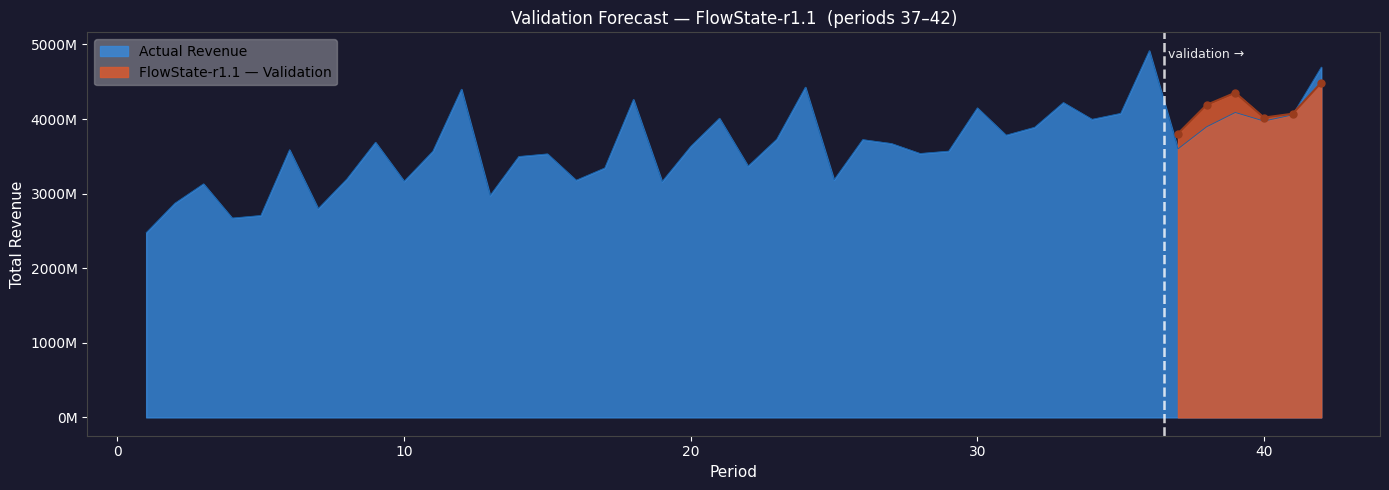

In [15]:
# ── Aggregate predictions by period & plot ──
agg_preds = {}
for t in range(HORIZON):
    period = VAL_CUTOFF + 1 + t   # 37 … 42
    agg_preds[period] = sum(
        preds[t] for preds in flowstate_results.values() if len(preds) > t
    )

plot_forecast_area(full_train, agg_preds, 'FlowState-r1.1', TARGET, PERIOD_COL)

---
## 6. Blind Forecast (Periods 43–48)

In [16]:
# ── Load hold-out set ──
val_blind = pd.read_parquet(VAL_PATH)
TEST_CUTOFF = full_train[PERIOD_COL].max()  # = 42
test_subsegments = sorted(val_blind[SUBSEG_COL].unique())
print(f'Hold-out set: {val_blind.shape} | Subsegments: {len(test_subsegments)} | Test cutoff: {TEST_CUTOFF}')

Hold-out set: (715, 110) | Subsegments: 124 | Test cutoff: 42


In [17]:
# ── Build test contexts ──
test_contexts, test_skipped = {}, []

for seg in test_subsegments:
    train_s = (full_train[full_train[SUBSEG_COL] == seg]
               .sort_values(PERIOD_COL)
               .dropna(subset=[TARGET]))
    if len(train_s) < 4:
        test_skipped.append(seg)
        continue
    test_contexts[seg] = train_s[TARGET].values.astype(float)

print(f'Contexts built: {len(test_contexts)} | Skipped: {len(test_skipped)}')
if test_skipped:
    print('Skipped:', test_skipped)

Contexts built: 122 | Skipped: 2
Skipped: ['SSI0278218', 'SSI0278468']


In [18]:
# ── Batch predict — test (single GPU call) ──
flowstate_test_results, flowstate_test_errors = {}, []

test_segs_ordered = list(test_contexts.keys())
test_max_len = max(len(test_contexts[s]) for s in test_segs_ordered)

# Front-pad shorter series to test_max_len (replicates first value)
test_padded = [
    np.concatenate([np.full(test_max_len - len(test_contexts[s]), test_contexts[s][0]), test_contexts[s]])
    for s in test_segs_ordered
]

# Shape: (test_max_len, N, 1) — batch_first=False
test_batch_tensor = (torch.tensor(np.stack(test_padded), dtype=torch.float32)
                     .T.unsqueeze(-1).to(device))

try:
    with torch.no_grad():
        test_forecast = flowstate_model(
            test_batch_tensor,
            scale_factor=SCALE_FACTOR,
            prediction_length=HORIZON,
            batch_first=False,
        )
    # Output: (N, 9 quantiles, HORIZON, 1) — index 4 = median
    flowstate_test_results = {
        seg: test_forecast.prediction_outputs[i, 4, :, 0].cpu().numpy()
        for i, seg in enumerate(test_segs_ordered)
    }
except Exception as e:
    flowstate_test_errors.append(str(e))

print(f'Results: {len(flowstate_test_results)} | Skipped: {len(test_skipped)}')
if flowstate_test_errors:
    print('Errors:', flowstate_test_errors)

Results: 122 | Skipped: 2


In [19]:
# ── Build submission DataFrame ──
rows = [
    {SUBSEG_COL: seg, PERIOD_COL: TEST_CUTOFF + 1 + t, 'Revenue_Predicted': float(p)}
    for seg, preds in flowstate_test_results.items()
    for t, p in enumerate(preds)
]
submission_df = (
    pd.DataFrame(rows)
    .merge(val_blind[[SUBSEG_COL, PERIOD_COL]], on=[SUBSEG_COL, PERIOD_COL], how='inner')
    .reset_index(drop=True)
)
print(f'Submission rows: {len(submission_df)}')  # Expected: 711
submission_df

Submission rows: 711


,TGL Business Subsegment,Anon Period,Revenue_Predicted
0,SSI02710,44,-1.589980e+02
1,SSI02710,45,6.201680e+02
2,SSI02710,48,1.316883e+03
3,SSI0271002,43,1.875631e+06
4,SSI0271002,44,1.850904e+06
...,...,...,...
706,SSI0708310,44,8.224019e+06
707,SSI0708310,45,7.867132e+06
708,SSI0708310,46,8.046127e+06
709,SSI0708310,47,8.341384e+06


SSI0278218 appears 3× in the validation set but not in the training set.  
SSI0278468 appears 1× in the validation set but not in the training set.

Both IDs are therefore excluded from the final prediction.

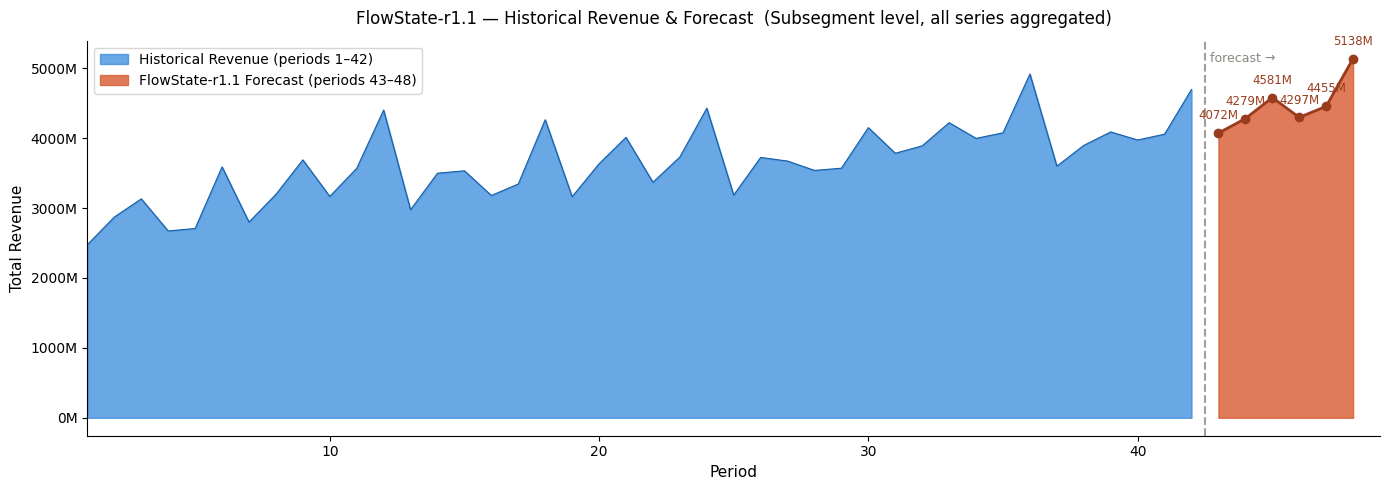

PosixPath('/content/drive/MyDrive/Coding/data/predictions/forecast_plot_flowstate-r1.1.png')

In [20]:
# ── Plot blind forecast ──
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

plot_forecast_comparison(
    train_df=full_train,
    submission_df=submission_df,
    period_col=PERIOD_COL,
    target_col=TARGET,
    best_model_name='FlowState-r1.1',
    output_dir=OUTPUT_DIR,
)